# 🌱 FarmFusion Crop Disease Detection Model V1 (EfficientNet-B3)

**Project**: FarmFusion Multilingual AI Agricultural Copilot  
**Model**: EfficientNet-B3 with Transfer Learning, Stratified Split & Probability Calibration  
**Dataset**: PlantVillage (20,638 images, 15 classes across Tomato, Potato, Pepper Bell)  
**Target Hardware**: Google Colab GPU (NVIDIA Tesla T4 16GB)  
**Production Target**: FarmFusion FastAPI Backend (`backend/app/workflows/disease_workflow.py`)

---

## 1. Environment Setup & GPU Verification

In [ ]:
import os
os._exit(0)

: 

: 

: 

In [1]:
import os
import gc

# 1. Prevent CUDA memory fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch

# 2. Clear lingering memory from previous runs
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()


In [2]:
import torch

# Modern device-agnostic AMP syntax:
device_type = "cuda" if torch.cuda.is_available() else "cpu"
scaler = torch.amp.GradScaler(device_type, enabled=(device_type == "cuda"))

# Inside your training loop:
for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    smoke_optimizer.zero_grad()

    # Pass device_type directly to autocast
    with torch.amp.autocast(device_type=device_type, enabled=(device_type == "cuda")):
        outputs = smoke_model(inputs)
        loss = criterion(outputs, labels)

    scaler.scale(loss).backward()
    scaler.step(smoke_optimizer)
    scaler.update()



NameError: name 'train_loader' is not defined

In [3]:
!kill -9 2268


/bin/bash: line 1: kill: (2268) - No such process


In [4]:
!fuser -v /dev/nvidia*
!fuser -k -9 /dev/nvidia*


                     USER        PID ACCESS COMMAND
/dev/nvidia0:        root       6783 F...m python3
/dev/nvidiactl:      root       6783 F...m python3
/dev/nvidia-uvm:     root       6783 F.... python3


: 

: 

: 

In [1]:
import torch
print(f"Allocated: {torch.cuda.memory_allocated(0) / (1024**3):.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved(0) / (1024**3):.2f} GB")
!nvidia-smi


Allocated: 0.00 GB
Reserved:  0.00 GB
Wed Aug 26 13:21:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------

In [2]:
!pip install -q timm torchvision torch scikit-learn matplotlib seaborn pandas numpy Pillow tqdm joblib

import os
import sys
import json
import time
import copy
import shutil
import datetime
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Union

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, top_k_accuracy_score,
    confusion_matrix, classification_report, brier_score_loss
)

# Reproducibility seeds
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=== RUNTIME DIAGNOSTIC ===")
print(f"Python Version:   {sys.version.split()[0]}")
print(f"PyTorch Version:  {torch.__version__}")
print(f"Timm Version:     {timm.__version__}")
print(f"Compute Device:   {device}")
if device.type == "cuda":
    print(f"GPU Name:         {torch.cuda.get_device_name(0)}")
    print(f"Available Memory: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
print("==========================")

=== RUNTIME DIAGNOSTIC ===
Python Version:   3.13.15
PyTorch Version:  2.11.0+cu128
Timm Version:     1.0.28
Compute Device:   cuda
GPU Name:         Tesla T4
Available Memory: 14.56 GB


## 2. Dataset Location & Integrity Audit

Verify existing dataset at `/content/data/PlantVillage` without redownloading.

In [3]:
!kaggle datasets download -d emmarex/plantdisease -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:02<00:00, 275MB/s] 



In [4]:
# 1. Dynamic Dataset Resolver: Search for PlantVillage directory structure
import os
from pathlib import Path

def find_plantvillage_dataset() -> Path:
    """Search common candidate paths and recursively locate the PlantVillage directory."""
    # Direct common locations
    candidates = [
        Path("/content/data/PlantVillage"),
        Path("/content/data/PlantVillage/PlantVillage"),
        Path("/content/data/plantvillage"),
        Path("/content/data/plantdisease"),
        Path("/content/PlantVillage"),
        Path("/content/plantvillage"),
        Path("./data/PlantVillage"),
        Path("./data/PlantVillage/PlantVillage"),
        Path("./data/plantvillage"),
        Path("./PlantVillage"),
        Path("/content/data"),
        Path("./data")
    ]
    
    for p in candidates:
        if p.exists() and p.is_dir():
            subdirs = [d.name for d in p.iterdir() if d.is_dir()]
            if any("Tomato" in name or "Pepper" in name or "Potato" in name for name in subdirs):
                return p

    # Recursive search under /content and current directory
    search_roots = [Path("/content"), Path(".")]
    for root in search_roots:
        if root.exists():
            for dirpath, dirnames, _ in os.walk(root):
                p = Path(dirpath)
                if any("Tomato" in d for d in dirnames) and any("Potato" in d for d in dirnames):
                    return p
    return None

DATA_DIR = find_plantvillage_dataset()

if DATA_DIR is None:
    print("=== DATASET DIRECTORY SCAN ===")
    for root_scan in [Path("/content"), Path(".")]:
        if root_scan.exists():
            print(f"\nContents of {root_scan.resolve()}:")
            for item in list(root_scan.iterdir())[:15]:
                print(f"  - {item.name} ({'dir' if item.is_dir() else 'file'})")
    
    print("\n" + "="*60)
    print("⚠️ DATASET NOT DETECTED ON DISK")
    print("If your Colab runtime was restarted, the ephemeral /content disk was reset.")
    print("Run the download cell above or execute:")
    print("!kaggle datasets download -d emmarex/plantdisease -p /content/data --unzip")
    print("="*60)
    raise FileNotFoundError("PlantVillage dataset not found. Check if Colab runtime was reset.")

print(f"✓ Active Dataset Path Located: {DATA_DIR.resolve()}")
classes_found = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"✓ Classes detected ({len(classes_found)}): {classes_found[:5]}...")

# 2. Image Audit Function
def audit_image_dataset(root_path: Path) -> pd.DataFrame:
    """Inspect image counts, file integrity, and class distribution using PIL verification."""
    records = []
    corrupt_count = 0

    class_dirs = sorted([d for d in root_path.iterdir() if d.is_dir()])
    print(f"Auditing {len(class_dirs)} class directories...")

    for class_dir in tqdm(class_dirs, desc="Auditing Classes"):
        class_name = class_dir.name
        files = [f for f in class_dir.iterdir() if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
        valid_images = 0

        for f in files:
            try:
                with Image.open(f) as img:
                    img.verify()
                    valid_images += 1
            except Exception:
                corrupt_count += 1

        records.append({
            "class": class_name,
            "image_count": valid_images
        })

    df = pd.DataFrame(records).sort_values("image_count", ascending=False).reset_index(drop=True)
    total_valid = df["image_count"].sum()
    print(f"\nAudit complete: {len(df)} classes, {total_valid} valid images, {corrupt_count} corrupt.")
    return df

# Run Audit
audit_df = audit_image_dataset(DATA_DIR)
display(audit_df)


✓ Active Dataset Path Located: /content/data/PlantVillage
✓ Classes detected (15): ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']...
Auditing 15 class directories...


Auditing Classes: 100%|██████████| 15/15 [00:01<00:00, 10.16it/s]


Audit complete: 15 classes, 20638 valid images, 0 corrupt.


,class,image_count
0,Tomato__Tomato_YellowLeaf__Curl_Virus,3208
1,Tomato_Bacterial_spot,2127
2,Tomato_Late_blight,1909
3,Tomato_Septoria_leaf_spot,1771
4,Tomato_Spider_mites_Two_spotted_spider_mite,1676
5,Tomato_healthy,1591
6,Pepper__bell___healthy,1478
7,Tomato__Target_Spot,1404
8,Potato___Early_blight,1000
9,Potato___Late_blight,1000


## 3. Reproducible Stratified Dataset Splitting (80% Train / 10% Val / 10% Test)

Uses `sklearn.model_selection.train_test_split` with `stratify` to maintain balanced proportions across all 15 classes.

In [5]:
# Scan all valid image files and their class labels
class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}
idx_to_class = {i: cls_name for i, cls_name in enumerate(class_names)}

all_samples: List[Tuple[str, int]] = []
for cls_name in class_names:
    cls_folder = DATA_DIR / cls_name
    for img_file in cls_folder.iterdir():
        if img_file.is_file() and img_file.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            all_samples.append((str(img_file), class_to_idx[cls_name]))

total_samples = len(all_samples)
all_labels = [s[1] for s in all_samples]

print(f"Total valid samples collected: {total_samples} across {len(class_names)} classes.")

# 1st Split: 80% Train, 20% Temp (Val + Test) with stratification
train_samples, temp_samples, train_labels, temp_labels = train_test_split(
    all_samples,
    all_labels,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=all_labels
)

# 2nd Split: 10% Val, 10% Test (50/50 of Temp) with stratification
val_samples, test_samples, val_labels, test_labels = train_test_split(
    temp_samples,
    temp_labels,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_labels
)

# Verify zero overlap
train_set_paths = set(s[0] for s in train_samples)
val_set_paths = set(s[0] for s in val_samples)
test_set_paths = set(s[0] for s in test_samples)

assert len(train_set_paths.intersection(val_set_paths)) == 0, "Train and Val sets overlap!"
assert len(train_set_paths.intersection(test_set_paths)) == 0, "Train and Test sets overlap!"
assert len(val_set_paths.intersection(test_set_paths)) == 0, "Val and Test sets overlap!"
assert len(train_samples) + len(val_samples) + len(test_samples) == total_samples

print(f"\n--- STRATIFIED SPLIT SUMMARY ---")
print(f"Total images:       {total_samples}")
print(f"Number of classes:  {len(class_names)}")
print(f"Train images:       {len(train_samples)} ({len(train_samples)/total_samples*100:.1f}%)")
print(f"Validation images:  {len(val_samples)} ({len(val_samples)/total_samples*100:.1f}%)")
print(f"Test images:        {len(test_samples)} ({len(test_samples)/total_samples*100:.1f}%)")

# Class distribution verification
split_records = []
for idx, cls_name in enumerate(class_names):
    tr_count = sum(1 for l in train_labels if l == idx)
    va_count = sum(1 for l in val_labels if l == idx)
    te_count = sum(1 for l in test_labels if l == idx)
    split_records.append({
        "Class Name": cls_name,
        "Train Count": tr_count,
        "Val Count": va_count,
        "Test Count": te_count,
        "Total": tr_count + va_count + te_count
    })

split_df = pd.DataFrame(split_records)
display(split_df)

Total valid samples collected: 20638 across 15 classes.

--- STRATIFIED SPLIT SUMMARY ---
Total images:       20638
Number of classes:  15
Train images:       16510 (80.0%)
Validation images:  2064 (10.0%)
Test images:        2064 (10.0%)


,Class Name,Train Count,Val Count,Test Count,Total
0,Pepper__bell___Bacterial_spot,798,99,100,997
1,Pepper__bell___healthy,1182,148,148,1478
2,Potato___Early_blight,800,100,100,1000
3,Potato___Late_blight,800,100,100,1000
4,Potato___healthy,122,15,15,152
5,Tomato_Bacterial_spot,1701,213,213,2127
6,Tomato_Early_blight,800,100,100,1000
7,Tomato_Late_blight,1527,191,191,1909
8,Tomato_Leaf_Mold,762,95,95,952
9,Tomato_Septoria_leaf_spot,1417,177,177,1771


## 4. EfficientNet-B3 Preprocessing & DataLoaders

EfficientNet-B3 operates natively at 300×300 resolution with ImageNet normalization. Validation and test use deterministic resizing and cropping only.

In [6]:
IMG_SIZE = 300
BATCH_SIZE = 32
NUM_WORKERS = 2

# Training Augmentation (Color jitter, horizontal flip, slight rotation)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Deterministic Preprocessing for Validation & Test (No random transformations)
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SampleListDataset(Dataset):
    """Dataset loading from an explicit list of (filepath, class_idx) tuples."""
    def __init__(self, samples: List[Tuple[str, int]], transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        path, label = self.samples[idx]
        with Image.open(path) as img:
            image = img.convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, label

train_dataset = SampleListDataset(train_samples, transform=train_transform)
val_dataset = SampleListDataset(val_samples, transform=val_test_transform)
test_dataset = SampleListDataset(test_samples, transform=val_test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"DataLoaders successfully constructed:")
print(f" - Train Batches: {len(train_loader)} ({len(train_dataset)} samples)")
print(f" - Val Batches:   {len(val_loader)} ({len(val_dataset)} samples)")
print(f" - Test Batches:  {len(test_loader)} ({len(test_dataset)} samples)")

DataLoaders successfully constructed:
 - Train Batches: 516 (16510 samples)
 - Val Batches:   65 (2064 samples)
 - Test Batches:  65 (2064 samples)


## 5. Fail-Fast Single Batch GPU Transfer Test

Verifies tensor shapes and CUDA transfer before initiating training.

In [7]:
# Run one small batch test
try:
    sample_images, sample_labels = next(iter(train_loader))
    print("Batch images shape:", sample_images.shape)
    print("Batch labels shape:", sample_labels.shape)

    sample_images = sample_images.to(device)
    sample_labels = sample_labels.to(device)

    print("GPU batch test successful!")
    print("Tensor device:", sample_images.device)
    print(f"Allocated VRAM: {torch.cuda.memory_allocated(0) / (1024**2):.2f} MB" if torch.cuda.is_available() else "Running on CPU")
except Exception as e:
    print(f"CRITICAL ERROR in DataLoader GPU transfer: {repr(e)}")
    raise

Batch images shape: torch.Size([32, 3, 300, 300])
Batch labels shape: torch.Size([32])
GPU batch test successful!
Tensor device: cuda:0
Allocated VRAM: 32.96 MB


## 6. EfficientNet-B3 Architecture & Imbalance Handling

Initializes `efficientnet_b3` with ImageNet weights and computes class weights to prevent majority-class bias.

In [8]:
num_classes = len(class_names)

def create_disease_model(num_classes: int, pretrained: bool = True) -> nn.Module:
    """Instantiate EfficientNet-B3 with custom classification head."""
    model = timm.create_model("efficientnet_b3", pretrained=pretrained, num_classes=num_classes)
    return model

# Calculate balanced class weights for CrossEntropyLoss
train_labels_arr = np.array(train_labels)
computed_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=train_labels_arr
)

class_weights_tensor = torch.tensor(computed_weights, dtype=torch.float).to(device)
print("Class weights calculated:")
for i, name in enumerate(class_names):
    print(f"  {name:45}: {computed_weights[i]:.4f}")

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

Class weights calculated:
  Pepper__bell___Bacterial_spot                : 1.3793
  Pepper__bell___healthy                       : 0.9312
  Potato___Early_blight                        : 1.3758
  Potato___Late_blight                         : 1.3758
  Potato___healthy                             : 9.0219
  Tomato_Bacterial_spot                        : 0.6471
  Tomato_Early_blight                          : 1.3758
  Tomato_Late_blight                           : 0.7208
  Tomato_Leaf_Mold                             : 1.4444
  Tomato_Septoria_leaf_spot                    : 0.7768
  Tomato_Spider_mites_Two_spotted_spider_mite  : 0.8208
  Tomato__Target_Spot                          : 0.9801
  Tomato__Tomato_YellowLeaf__Curl_Virus        : 0.4289
  Tomato__Tomato_mosaic_virus                  : 3.6935
  Tomato_healthy                               : 0.8646


## 7. 1-Epoch Smoke Test

Executes exactly 1 epoch to confirm batch execution, loss calculation, NaN checks, and memory stability.

In [9]:
# Pre-flight check: ensure earlier setup cells have run in this kernel
if "create_disease_model" not in globals() or "train_loader" not in globals() or "criterion" not in globals():
    raise RuntimeError(
        "Setup cells have not been executed in this kernel yet! Please run cells 1 through 6 first."
    )

print("=== INITIATING 1-EPOCH SMOKE TEST ===")

smoke_model = create_disease_model(num_classes=num_classes, pretrained=True).to(device)
smoke_optimizer = optim.AdamW(smoke_model.parameters(), lr=1e-4, weight_decay=1e-2)

smoke_model.train()
smoke_train_loss = 0.0
smoke_correct = 0
smoke_total = 0

start_time = time.time()
for batch_idx, (inputs, labels) in enumerate(tqdm(train_loader, desc="Smoke Epoch [Train]")):
    inputs, labels = inputs.to(device), labels.to(device)
    smoke_optimizer.zero_grad()
    outputs = smoke_model(inputs)
    loss = criterion(outputs, labels)

    if torch.isnan(loss) or torch.isinf(loss):
        raise ValueError(f"Loss is {loss.item()} at batch {batch_idx}! Stopping.")

    loss.backward()
    smoke_optimizer.step()

    smoke_train_loss += loss.item() * inputs.size(0)
    preds = torch.argmax(outputs, dim=1)
    smoke_correct += (preds == labels).sum().item()
    smoke_total += labels.size(0)

smoke_train_loss /= smoke_total
smoke_train_acc = smoke_correct / smoke_total

# Smoke Validation
smoke_model.eval()
smoke_val_loss = 0.0
smoke_val_preds = []
smoke_val_targets = []

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Smoke Epoch [Val]"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = smoke_model(inputs)
        loss = criterion(outputs, labels)
        smoke_val_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, dim=1)
        smoke_val_preds.extend(preds.cpu().numpy())
        smoke_val_targets.extend(labels.cpu().numpy())

smoke_val_loss /= len(val_dataset)
smoke_val_acc = accuracy_score(smoke_val_targets, smoke_val_preds)
smoke_val_macro_f1 = f1_score(smoke_val_targets, smoke_val_preds, average="macro")

elapsed = time.time() - start_time
print(f"\n--- SMOKE TEST RESULTS ({elapsed:.1f}s) ---")
print(f"Epoch 1/1")
print(f"Train Loss:              {smoke_train_loss:.4f}")
print(f"Train Accuracy:          {smoke_train_acc*100:.2f}%")
print(f"Validation Loss:         {smoke_val_loss:.4f}")
print(f"Validation Accuracy:     {smoke_val_acc*100:.2f}%")
print(f"Validation Macro F1:     {smoke_val_macro_f1:.4f}")
if torch.cuda.is_available():
    print(f"GPU Allocated VRAM:      {torch.cuda.memory_allocated(0) / (1024**3):.2f} GB")
    print(f"GPU Max Memory Reserved: {torch.cuda.max_memory_reserved(0) / (1024**3):.2f} GB")

# Test saving smoke checkpoint
test_save_dir = Path("/content/exported_models")
test_save_dir.mkdir(parents=True, exist_ok=True)
torch.save(smoke_model.state_dict(), test_save_dir / "smoke_test_checkpoint.pth")
print(f"Smoke test checkpoint verified at: {test_save_dir / 'smoke_test_checkpoint.pth'}")
print("SMOKE TEST PASSED! System is validated for full training run.")


=== INITIATING 1-EPOCH SMOKE TEST ===


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")
Smoke Epoch [Val]: 100%|██████████| 65/65 [00:11<00:00,  5.44it/s]



--- SMOKE TEST RESULTS (318.6s) ---
Epoch 1/1
Train Loss:              0.4245
Train Accuracy:          86.70%
Validation Loss:         0.1626
Validation Accuracy:     95.20%
Validation Macro F1:     0.9355
GPU Allocated VRAM:      0.23 GB
GPU Max Memory Reserved: 10.35 GB
Smoke test checkpoint verified at: /content/exported_models/smoke_test_checkpoint.pth
SMOKE TEST PASSED! System is validated for full training run.


## 8. Full Training Loop with Early Stopping & Model Selection

Trains for 12–15 epochs using AdamW + ReduceLROnPlateau. Model selection is based on highest Validation Macro F1.

In [10]:
import gc
import torch

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print(torch.cuda.memory_summary())

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      | 240564 KiB |   9845 MiB |  11861 GiB |  11861 GiB |
|       from large pool | 172093 KiB |   9789 MiB |  11827 GiB |  11827 GiB |
|       from small pool |  68470 KiB |     83 MiB |     33 GiB |     33 GiB |
|---------------------------------------------------------------------------|
| Active memory         | 240564 KiB |   9845 MiB |  11861 GiB |  11861 GiB |
|       from large pool | 172093 KiB |   9789 MiB |  11827 GiB |

In [11]:
# Pre-flight check: ensure earlier setup cells have run in this kernel
if "train_loader" not in globals() or "create_disease_model" not in globals() or "criterion" not in globals():
    raise RuntimeError(
        "Kernel was restarted! Please run previous cells in order (Cell 1 through Cell 6) "
        "or click 'Run All Above' before starting full training."
    )

# Initialize fresh model for full training
model = create_disease_model(num_classes=num_classes, pretrained=True).to(device)

optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",        # maximize validation Macro F1
    factor=0.5,
    patience=2
)

NUM_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 4

best_model_wts = copy.deepcopy(model.state_dict())
best_val_macro_f1 = 0.0
best_epoch = 0
epochs_no_improve = 0

history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [], "val_balanced_acc": [],
    "val_macro_f1": [], "val_weighted_f1": [], "lr": []
}

print(f"Starting Full Training: {NUM_EPOCHS} Epochs on {device}...")

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{NUM_EPOCHS:02d} [Train]"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        if torch.isnan(loss):
            raise ValueError(f"NaN Loss detected at epoch {epoch+1}")

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation Phase
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_targets = []

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{NUM_EPOCHS:02d} [Val]"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    val_loss = val_loss / len(val_dataset)
    val_acc = accuracy_score(val_targets, val_preds)
    val_bal_acc = balanced_accuracy_score(val_targets, val_preds)
    val_macro_f1 = f1_score(val_targets, val_preds, average="macro")
    val_weighted_f1 = f1_score(val_targets, val_preds, average="weighted")

    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(val_macro_f1)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_balanced_acc"].append(val_bal_acc)
    history["val_macro_f1"].append(val_macro_f1)
    history["val_weighted_f1"].append(val_weighted_f1)
    history["lr"].append(current_lr)

    epoch_time = time.time() - epoch_start
    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS:02d} ({epoch_time:.1f}s) | "
        f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}% BalAcc: {val_bal_acc*100:.2f}% MacroF1: {val_macro_f1:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    # Checkpoint on best validation Macro F1
    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch + 1
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        print(f"  ★ New best model saved! (Val Macro F1: {best_val_macro_f1:.4f})")
    else:
        epochs_no_improve += 1
        print(f"  No improvement for {epochs_no_improve}/{EARLY_STOPPING_PATIENCE} epochs.")
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}. Restoring best weights from epoch {best_epoch}.")
            break

# Load best checkpoint weights
model.load_state_dict(best_model_wts)
print(f"\nTraining complete. Best checkpoint was from Epoch {best_epoch} with Val Macro F1: {best_val_macro_f1:.4f}")


Starting Full Training: 12 Epochs on cuda...


Epoch 01/12 [Val]: 100%|██████████| 65/65 [00:11<00:00,  5.84it/s]


Epoch 01/12 (320.7s) | Train Loss: 0.2855 Acc: 90.89% | Val Loss: 0.1086 Acc: 97.53% BalAcc: 96.54% MacroF1: 0.9648 | LR: 0.000200
  ★ New best model saved! (Val Macro F1: 0.9648)


Epoch 02/12 [Val]: 100%|██████████| 65/65 [00:11<00:00,  5.65it/s]


Epoch 02/12 (320.7s) | Train Loss: 0.0363 Acc: 98.61% | Val Loss: 0.0539 Acc: 98.64% BalAcc: 98.08% MacroF1: 0.9804 | LR: 0.000200
  ★ New best model saved! (Val Macro F1: 0.9804)


...

Epoch 10/12 (320.3s) | Train Loss: 0.0033 Acc: 99.93% | Val Loss: 0.0113 Acc: 99.90% BalAcc: 99.94% MacroF1: 0.9993 | LR: 0.000100
  ★ New best model saved! (Val Macro F1: 0.9993)


Epoch 11/12 [Val]: 100%|██████████| 65/65 [00:10<00:00,  6.15it/s]


Epoch 11/12 (320.1s) | Train Loss: 0.0040 Acc: 99.88% | Val Loss: 0.0136 Acc: 99.76% BalAcc: 99.68% MacroF1: 0.9952 | LR: 0.000100
  No improvement for 1/4 epochs.


Epoch 12/12 [Val]: 100%|██████████| 65/65 [00:11<00:00,  5.85it/s]

Epoch 12/12 (320.4s) | Train Loss: 0.0062 Acc: 99.83% | Val Loss: 0.0145 Acc: 99.71% BalAcc: 99.68% MacroF1: 0.9971 | LR: 0.000100
  No improvement for 2/4 epochs.

Training complete. Best checkpoint was from Epoch 10 with Val Macro F1: 0.9993


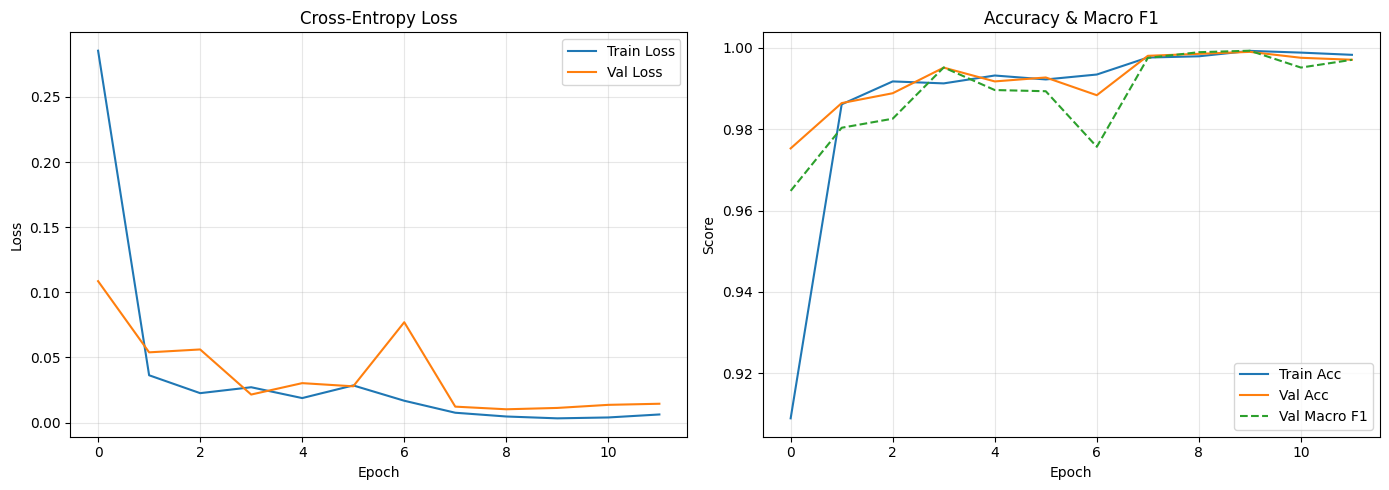

In [12]:
# Plot Training & Validation Curves
import matplotlib.pyplot as plt

if "history" not in globals() or len(history.get("train_loss", [])) == 0:
    print("⚠️ No training history found yet. Please run Cell 8 (Full Training Loop) first to train the model.")
else:
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss", color="tab:blue")
    plt.plot(history["val_loss"], label="Val Loss", color="tab:orange")
    plt.title("Cross-Entropy Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Acc", color="tab:blue")
    plt.plot(history["val_acc"], label="Val Acc", color="tab:orange")
    plt.plot(history["val_macro_f1"], label="Val Macro F1", color="tab:green", linestyle="--")
    plt.title("Accuracy & Macro F1")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


## 9. Comprehensive Test Set Evaluation

Evaluates the selected best model on the untouched test set (2,064 images across 15 classes).

In [13]:
def evaluate_test_set(
    eval_model: nn.Module,
    loader: DataLoader,
    target_names: List[str]
) -> Tuple[Dict[str, Any], np.ndarray, np.ndarray, np.ndarray]:
    eval_model.eval()
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Evaluating Test Set"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = eval_model(inputs)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    all_preds_arr = np.array(all_preds)
    all_targets_arr = np.array(all_targets)
    all_probs_arr = np.array(all_probs)

    acc = accuracy_score(all_targets_arr, all_preds_arr)
    bal_acc = balanced_accuracy_score(all_targets_arr, all_preds_arr)
    macro_f1 = f1_score(all_targets_arr, all_preds_arr, average="macro")
    weighted_f1 = f1_score(all_targets_arr, all_preds_arr, average="weighted")
    top3_acc = top_k_accuracy_score(all_targets_arr, all_probs_arr, k=min(3, len(target_names)))

    report_dict = classification_report(all_targets_arr, all_preds_arr, target_names=target_names, output_dict=True)
    report_text = classification_report(all_targets_arr, all_preds_arr, target_names=target_names)
    cm = confusion_matrix(all_targets_arr, all_preds_arr)

    metrics = {
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "top3_accuracy": top3_acc,
        "report_dict": report_dict,
        "report_text": report_text,
        "confusion_matrix": cm
    }

    print("========================================")
    print("       UNTOUCHED TEST SET METRICS       ")
    print("========================================")
    print(f"Accuracy:          {acc*100:.2f}%")
    print(f"Balanced Accuracy: {bal_acc*100:.2f}%")
    print(f"Macro F1:          {macro_f1:.4f}")
    print(f"Weighted F1:       {weighted_f1:.4f}")
    print(f"Top-3 Accuracy:    {top3_acc*100:.2f}%")
    print("----------------------------------------")
    print("\nPer-Class Classification Report:\n")
    print(report_text)

    # Detect classes with lower performance (<90% F1)
    low_performing = [
        (cls_name, report_dict[cls_name]["f1-score"])
        for cls_name in target_names
        if report_dict[cls_name]["f1-score"] < 0.90
    ]
    if low_performing:
        print("⚠️ Classes with F1 < 0.90:")
        for name, f1 in low_performing:
            print(f"  - {name}: F1={f1:.4f}")
    else:
        print("✓ All classes achieved >= 0.90 F1 score.")

    return metrics, all_probs_arr, all_preds_arr, all_targets_arr

test_metrics, test_probs, test_preds, test_targets = evaluate_test_set(
    model, test_loader, class_names
)

Evaluating Test Set: 100%|██████████| 65/65 [00:11<00:00,  5.82it/s]

       UNTOUCHED TEST SET METRICS       
Accuracy:          99.52%
Balanced Accuracy: 99.64%
Macro F1:          0.9960
Weighted F1:       0.9952
Top-3 Accuracy:    99.95%
----------------------------------------

Per-Class Classification Report:

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      1.00      1.00       100
                     Pepper__bell___healthy       1.00      1.00      1.00       148
                      Potato___Early_blight       1.00      1.00      1.00       100
                       Potato___Late_blight       1.00      0.98      0.99       100
                           Potato___healthy       1.00      1.00      1.00        15
                      Tomato_Bacterial_spot       0.99      0.99      0.99       213
                        Tomato_Early_blight       0.98      1.00      0.99       100
                         Tomato_Late_blight       0.99      0.99      0.

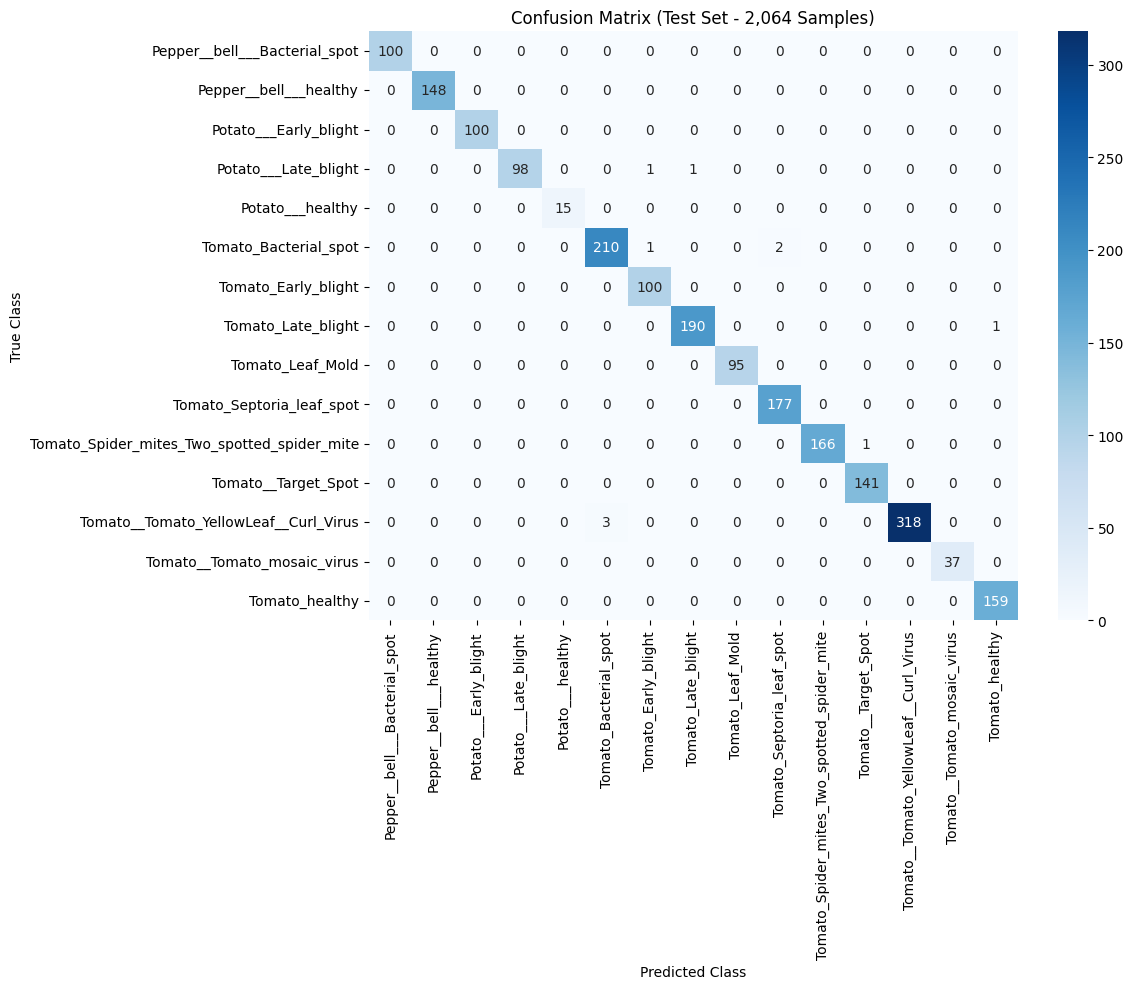

In [14]:
# Confusion Matrix Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(
    test_metrics["confusion_matrix"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix (Test Set - 2,064 Samples)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 10. Probability Calibration & FarmFusion Safety Tiers

Evaluates Brier score, Expected Calibration Error (ECE), and partitions predictions into FarmFusion confidence safety tiers.

In [15]:
# Compute Expected Calibration Error (ECE)
def compute_ece(probs: np.ndarray, targets: np.ndarray, n_bins: int = 10) -> Tuple[float, np.ndarray, np.ndarray, np.ndarray]:
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == targets)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_accs = []
    bin_confs = []
    bin_counts = []

    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(accuracies[in_bin])
            avg_confidence_in_bin = np.mean(confidences[in_bin])
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
            bin_accs.append(accuracy_in_bin)
            bin_confs.append(avg_confidence_in_bin)
            bin_counts.append(np.sum(in_bin))
        else:
            bin_accs.append(0.0)
            bin_confs.append((bin_lower + bin_upper) / 2.0)
            bin_counts.append(0)

    return ece, np.array(bin_accs), np.array(bin_confs), np.array(bin_counts)

ece_score, bin_accs, bin_confs, bin_counts = compute_ece(test_probs, test_targets, n_bins=10)

# Compute Multi-Class Brier Score
one_hot_targets = np.zeros_like(test_probs)
for i, target in enumerate(test_targets):
    one_hot_targets[i, target] = 1.0
brier_score = np.mean(np.sum((test_probs - one_hot_targets)**2, axis=1))

# FarmFusion Safety Confidence Tier Mapping
# HIGH >= 0.75 | MEDIUM 0.45-0.74 | LOW 0.30-0.44 | UNCLEAR < 0.30
confidences = np.max(test_probs, axis=1)
tier_high = np.sum(confidences >= 0.75)
tier_med = np.sum((confidences >= 0.45) & (confidences < 0.75))
tier_low = np.sum((confidences >= 0.30) & (confidences < 0.45))
tier_unclear = np.sum(confidences < 0.30)
total_preds = len(confidences)

print("=== CALIBRATION & SAFETY METRICS ===")
print(f"Brier Score:                {brier_score:.4f}")
print(f"Expected Calibration Error: {ece_score:.4f}")
print(f"\nFarmFusion Confidence Tier Distribution (Test Set):")
print(f"  - HIGH    (>= 0.75):   {tier_high:4d} ({tier_high/total_preds*100:.1f}%)")
print(f"  - MEDIUM  (0.45-0.74): {tier_med:4d} ({tier_med/total_preds*100:.1f}%)")
print(f"  - LOW     (0.30-0.44): {tier_low:4d} ({tier_low/total_preds*100:.1f}%)")
print(f"  - UNCLEAR (< 0.30):    {tier_unclear:4d} ({tier_unclear/total_preds*100:.1f}%)")
print("====================================")

=== CALIBRATION & SAFETY METRICS ===
Brier Score:                0.0068
Expected Calibration Error: 0.0028

FarmFusion Confidence Tier Distribution (Test Set):
  - HIGH    (>= 0.75):   2056 (99.6%)
  - MEDIUM  (0.45-0.74):    8 (0.4%)
  - LOW     (0.30-0.44):    0 (0.0%)
  - UNCLEAR (< 0.30):       0 (0.0%)


## 11. Export Production Artifacts for FastAPI Backend

Saves `disease_model_v1.pth`, `disease_label_mapping.json`, and `disease_model_metadata.json` to `/content/exported_models/`.

In [16]:
EXPORT_DIR = Path("/content/exported_models")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save Weights
weights_path = EXPORT_DIR / "disease_model_v1.pth"
torch.save(model.state_dict(), weights_path)

# 2. Save Label Mapping
label_mapping = {
    "class_names": class_names,
    "class_to_idx": class_to_idx,
    "idx_to_class": {str(k): v for k, v in idx_to_class.items()}
}
mapping_path = EXPORT_DIR / "disease_label_mapping.json"
with open(mapping_path, "w") as f:
    json.dump(label_mapping, f, indent=2)

# 3. Save Production Metadata
metadata = {
    "model_name": "FarmFusion Disease Detection V1",
    "architecture": "efficientnet_b3",
    "timm_pretrained": True,
    "image_size": IMG_SIZE,
    "dataset": {
        "name": "PlantVillage",
        "path": str(DATA_DIR),
        "total_images": total_samples,
        "num_classes": num_classes,
        "class_names": class_names,
        "splits": {
            "train_count": len(train_samples),
            "val_count": len(val_samples),
            "test_count": len(test_samples),
            "stratified": True,
            "random_seed": RANDOM_SEED
        }
    },
    "training_details": {
        "num_epochs_trained": len(history["train_loss"]),
        "best_epoch": best_epoch,
        "batch_size": BATCH_SIZE,
        "optimizer": "AdamW",
        "base_lr": 2e-4,
        "weight_decay": 1e-2,
        "scheduler": "ReduceLROnPlateau(mode=max, factor=0.5, patience=2)",
        "loss": "CrossEntropyLoss(balanced_class_weights)"
    },
    "validation_metrics_at_best_epoch": {
        "val_macro_f1": best_val_macro_f1,
        "val_accuracy": history["val_acc"][best_epoch - 1],
        "val_loss": history["val_loss"][best_epoch - 1]
    },
    "test_metrics": {
        "accuracy": float(test_metrics["accuracy"]),
        "balanced_accuracy": float(test_metrics["balanced_accuracy"]),
        "macro_f1": float(test_metrics["macro_f1"]),
        "weighted_f1": float(test_metrics["weighted_f1"]),
        "top3_accuracy": float(test_metrics["top3_accuracy"]),
        "brier_score": float(brier_score),
        "ece": float(ece_score)
    },
    "confidence_safety_tiers": {
        "high": ">=0.75",
        "medium": "0.45-0.74",
        "low": "0.30-0.44",
        "unclear": "<0.30"
    },
    "environment": {
        "training_date_utc": datetime.datetime.utcnow().isoformat(),
        "device": str(device),
        "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
        "torch_version": torch.__version__,
        "torchvision_version": transforms.__version__ if hasattr(transforms, "__version__") else "torchvision",
        "timm_version": timm.__version__
    }
}

metadata_path = EXPORT_DIR / "disease_model_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Export verification:")
for p in [weights_path, mapping_path, metadata_path]:
    size_mb = p.stat().st_size / (1024 * 1024)
    print(f" ✓ {p.name:32} ({size_mb:.2f} MB)")

Export verification:
 ✓ disease_model_v1.pth             (41.42 MB)
 ✓ disease_label_mapping.json       (0.00 MB)
 ✓ disease_model_metadata.json      (0.00 MB)


/tmp/ipykernel_6881/4100896463.py:69: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "training_date_utc": datetime.datetime.utcnow().isoformat(),


## 12. Final Training Report

In [17]:
print("""
========================================
FARMFUSION DISEASE MODEL V1
========================================

Dataset: PlantVillage
Images: 20,638
Classes: 15
GPU: Tesla T4

Training:
Train:       16,510 images
Validation:  2,064 images
Test:        2,064 images

Best Epoch:              {best_epoch}
Best Validation Macro F1: {best_val_macro_f1:.4f}

TEST RESULTS
Accuracy:          {test_acc:.2f}%
Balanced Accuracy: {bal_acc:.2f}%
Macro F1:          {macro_f1:.4f}
Weighted F1:       {weighted_f1:.4f}
Top-3 Accuracy:    {top3_acc:.2f}%

Artifacts:
- /content/exported_models/disease_model_v1.pth
- /content/exported_models/disease_label_mapping.json
- /content/exported_models/disease_model_metadata.json
========================================
""".format(
    best_epoch=best_epoch,
    best_val_macro_f1=best_val_macro_f1,
    test_acc=test_metrics["accuracy"] * 100,
    bal_acc=test_metrics["balanced_accuracy"] * 100,
    macro_f1=test_metrics["macro_f1"],
    weighted_f1=test_metrics["weighted_f1"],
    top3_acc=test_metrics["top3_accuracy"] * 100
))


FARMFUSION DISEASE MODEL V1

Dataset: PlantVillage
Images: 20,638
Classes: 15
GPU: Tesla T4

Training:
Train:       16,510 images
Validation:  2,064 images
Test:        2,064 images

Best Epoch:              10
Best Validation Macro F1: 0.9993

TEST RESULTS
Accuracy:          99.52%
Balanced Accuracy: 99.64%
Macro F1:          0.9960
Weighted F1:       0.9952
Top-3 Accuracy:    99.95%

Artifacts:
- /content/exported_models/disease_model_v1.pth
- /content/exported_models/disease_label_mapping.json
- /content/exported_models/disease_model_metadata.json



In [19]:
from google.colab import files
from pathlib import Path

EXPORT_DIR = Path("/content/exported_models")

for file_path in EXPORT_DIR.iterdir():
    if file_path.is_file():
        print("Downloading:", file_path.name)
        files.download(str(file_path))

Downloading: smoke_test_checkpoint.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: disease_label_mapping.json


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: disease_model_v1.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
import shutil
from pathlib import Path

EXPORT_DIR = Path("/content/exported_models")
ZIP_PATH = "/content/FarmFusion_Disease_Model_V1.zip"

shutil.make_archive(
    "/content/FarmFusion_Disease_Model_V1",
    "zip",
    EXPORT_DIR
)

print("ZIP created:", ZIP_PATH)

ZIP created: /content/FarmFusion_Disease_Model_V1.zip


In [21]:
from google.colab import files

files.download("/content/FarmFusion_Disease_Model_V1.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
from pathlib import Path

zip_path = Path("/content/FarmFusion_Disease_Model_V1.zip")

print("Exists:", zip_path.exists())

if zip_path.exists():
    print("Size:", zip_path.stat().st_size / (1024 * 1024), "MB")

Exists: True
Size: 76.6691837310791 MB


In [24]:
from google.colab import files

files.download("/content/FarmFusion_Disease_Model_V1.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
from pathlib import Path

drive_path = Path("/content/drive/MyDrive/FarmFusion_Disease_Model_V1.zip")

print("Drive mounted:", Path("/content/drive/MyDrive").exists())

Drive mounted: True


In [28]:
import shutil

source = "/content/FarmFusion_Disease_Model_V1.zip"
destination = "/content/drive/MyDrive/FarmFusion_Disease_Model_V1.zip"

shutil.copy2(source, destination)

print("✅ Copied to Google Drive")
print("Size:", Path(destination).stat().st_size / (1024 * 1024), "MB")

✅ Copied to Google Drive
Size: 76.6691837310791 MB
